# P01 (basic) — Wie das Gehirn zwei Sinne verschmilzt: inverse-Varianz-Fusion

**Modul 18 — Multimodal Interfaces**

In diesem Projekt rechnest du das **Herzstück multimodaler Fusion** selbst nach: die
**inverse-Varianz-Gewichtung** (Maximum-Likelihood-Integration). Sie beantwortet die Frage:
*Wenn zwei Modalitäten (z. B. Sehen und Tasten) denselben Wert verrauscht schätzen — was ist die
beste gemeinsame Schätzung?*

Das ist zugleich die direkte Fortsetzung des **Komplementärfilters aus Modul 17** (Gyro + Accel):
dieselbe Formel, andere Sinne. Und es ist die Mathematik hinter dem berühmten Experiment von
**Ernst & Banks (2002)**, das zeigte, dass das menschliche Gehirn *genau so* fusioniert.

### Ziel
Nach diesem Projekt kannst du …
- die inverse-Varianz-Fusion aus der Log-Likelihood herleiten und im Code umsetzen,
- zeigen, dass die Fusion **immer präziser** ist als jede Einzelmodalität ($\sigma_{fus}^2 \le \min$),
- den **reliabilitätsbasierten Wahrnehmungs-Shift** bei Sinneskonflikt reproduzieren
  (die zentrale Ernst-Banks-Vorhersage),
- den **Diskriminationsgewinn** (kleinere JND) messen.

### Format
Jupyter-Notebook — ideal, weil wir Formel, Simulation, Zahlen und Plots direkt nebeneinander sehen.

### Vorwissen
Gauß-Verteilung, Varianz, ein wenig Wahrscheinlichkeitsrechnung. Kapitel 8–9 des Modul-18-Skripts.

### Aufgaben
Die meisten Zellen sind vorgegeben. An den mit `# TODO` markierten Stellen füllst **du** die
Kernformeln ein. Die vollständige Lösung liegt in `solution/cue_integration_solution.ipynb` —
**Dies ist die vollständige Lösung.**


## Setup

Wir brauchen nur `numpy` und `matplotlib`. Beides ist in der Repo-`.venv` vorhanden.
Ein fester Seed macht alle Zufallszahlen reproduzierbar.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)  # Reproduzierbarkeit
N = 40000                        # Zahl simulierter Wahrnehmungen


## Teil A — Zwei verrauschte Sensoren optimal verschmelzen

Ein Objekt hat die wahre Kantenhöhe `s_true = 55.0` mm. Zwei Modalitäten schätzen sie unabhängig
und verrauscht (Gauß):

$$\hat{s}_V \sim \mathcal{N}(s, \sigma_V^2), \qquad \hat{s}_H \sim \mathcal{N}(s, \sigma_H^2)$$

Das **Sehen** ist hier präziser ($\sigma_V = 1$ mm) als das **Tasten** ($\sigma_H = 2$ mm).

Die **Reliabilität** einer Modalität ist die inverse Varianz $r = 1/\sigma^2$. Die optimale
(Maximum-Likelihood-)Fusion gewichtet **proportional zur Reliabilität**:

$$\hat{s} = w_V\,\hat{s}_V + w_H\,\hat{s}_H, \qquad
  w_V = \frac{1/\sigma_V^2}{1/\sigma_V^2 + 1/\sigma_H^2}, \quad
  w_H = \frac{1/\sigma_H^2}{1/\sigma_V^2 + 1/\sigma_H^2}$$

und die Fusion ist **präziser als jede Einzelmodalität**:

$$\frac{1}{\sigma_{fus}^2} = \frac{1}{\sigma_V^2} + \frac{1}{\sigma_H^2}
  \;\Longrightarrow\; \sigma_{fus}^2 \le \min(\sigma_V^2, \sigma_H^2).$$

**Deine Aufgabe:** Fülle die Gewichte, die fusionierte Schätzung und $\sigma_{fus}$ ein.

In [2]:
s_true  = 55.0   # wahre Kantenhoehe in mm
sigma_V = 1.0    # Sehen: praeziser
sigma_H = 2.0    # Tasten: unpraeziser

# Simuliere N unabhaengige verrauschte Messungen je Modalitaet
vis = rng.normal(s_true, sigma_V, N)
hap = rng.normal(s_true, sigma_H, N)

# Reliabilitaeten (inverse Varianzen)
r_V = 1.0 / sigma_V**2
r_H = 1.0 / sigma_H**2

# inverse-Varianz-Gewichte (addieren sich zu 1)
w_V = r_V / (r_V + r_H)
w_H = r_H / (r_V + r_H)

# fusionierte Schaetzung (elementweise, pro Wahrnehmung)
fused = w_V * vis + w_H * hap

# vorhergesagte Fusionsstandardabweichung sigma_fus
sigma_fus_pred = np.sqrt(1.0 / (r_V + r_H))

print(f"Gewichte:  w_V = {w_V:.3f},  w_H = {w_H:.3f}  (Summe {w_V+w_H:.3f})")
print(f"empirisch: std(vis)={vis.std():.3f}  std(hap)={hap.std():.3f}  std(fused)={fused.std():.3f}")
print(f"vorhergesagt: sigma_fus = {sigma_fus_pred:.3f}")
print(f"Ist die Fusion praeziser als der bessere Sensor? {fused.std() < min(sigma_V, sigma_H)}")


Gewichte:  w_V = 0.800,  w_H = 0.200  (Summe 1.000)
empirisch: std(vis)=1.005  std(hap)=2.002  std(fused)=0.895
vorhergesagt: sigma_fus = 0.894
Ist die Fusion praeziser als der bessere Sensor? True


**Erwartung / Selbstcheck.** Mit $\sigma_V=1$, $\sigma_H=2$:
- $r_V = 1$, $r_H = 0.25$ → $w_V = 0.8$, $w_H = 0.2$ (das präzisere Sehen bekommt 80 % Gewicht).
- $\sigma_{fus} = \sqrt{1/1.25} = \sqrt{0.8} \approx 0.894$ mm — **kleiner als 1 mm**, also präziser als *jeder* Einzelsensor.
- Die empirische `std(fused)` sollte fast exakt 0.894 treffen.

Der Plot zeigt die drei Verteilungen: die Fusion (grün) ist am schmalsten.

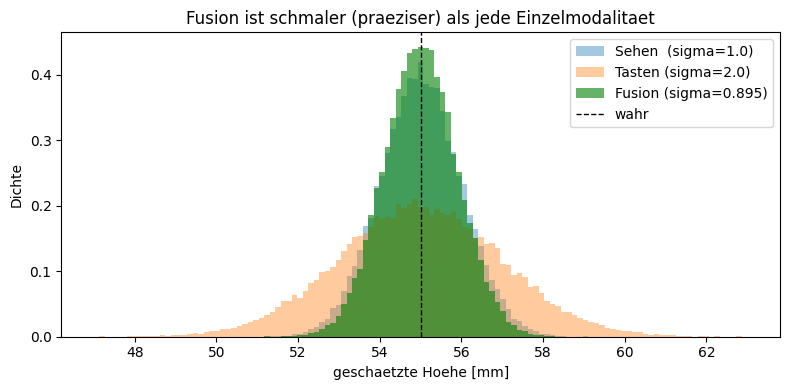

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(s_true - 8, s_true + 8, 120)
ax.hist(vis,   bins=bins, alpha=0.4, density=True, label=f"Sehen  (sigma={sigma_V})")
ax.hist(hap,   bins=bins, alpha=0.4, density=True, label=f"Tasten (sigma={sigma_H})")
ax.hist(fused, bins=bins, alpha=0.6, density=True, color="green",
        label=f"Fusion (sigma={fused.std():.3f})")
ax.axvline(s_true, color="k", ls="--", lw=1, label="wahr")
ax.set_xlabel("geschaetzte Hoehe [mm]"); ax.set_ylabel("Dichte")
ax.set_title("Fusion ist schmaler (praeziser) als jede Einzelmodalitaet")
ax.legend(); fig.tight_layout(); plt.show()


## Teil B — Der Ernst-Banks-Kern: Wahrnehmungs-Shift bei Sinneskonflikt

Jetzt das eigentliche Experiment. Ernst & Banks (2002) bauten heimlich einen **Konflikt** ein:
Das Gesehene und das Getastete sagten *verschiedene* Werte. Ihre Vorhersage: Der wahrgenommene
Wert liegt beim **reliabilitätsgewichteten Mittel** der beiden — und wandert zur *zuverlässigeren*
Modalität, wenn man die andere verrauscht.

Wir simulieren das: Sehen ist um `s_V` zentriert, Tasten um `s_H` (Konflikt von 4 mm). Der
"wahrgenommene" Wert ist der Mittelwert der fusionierten Schätzung.

**Deine Aufgabe:** Berechne den *vorhergesagten* Wahrnehmungswert `percept_pred` aus den
inverse-Varianz-Gewichten (dieselbe Formel wie Teil A, angewandt auf die Zentren `s_V`, `s_H`).

In [4]:
s_V, s_H = 53.0, 57.0   # Konflikt: Sehen sagt 53, Tasten sagt 57

def perceived(sigma_V, sigma_H, n=N):
    r_V, r_H = 1/sigma_V**2, 1/sigma_H**2
    wV, wH = r_V/(r_V+r_H), r_H/(r_V+r_H)
    v = rng.normal(s_V, sigma_V, n)
    h = rng.normal(s_H, sigma_H, n)
    fused = wV*v + wH*h
    percept_pred = wV*s_V + wH*s_H
    return fused.mean(), percept_pred, wV

# Fall 1: scharfes Sehen (sigma_V=1) -> Wahrnehmung nahe am Sehen (53)
m1, p1, wv1 = perceived(1.0, 2.0)
# Fall 2: verrauschtes Sehen (sigma_V=4) -> Gewicht wandert zum Tasten -> Wahrnehmung nahe 57
m2, p2, wv2 = perceived(4.0, 2.0)

print(f"scharfes  Sehen: w_V={wv1:.2f} -> Wahrnehmung {m1:.2f} mm (vorhergesagt {p1:.2f})")
print(f"unscharfes Sehen: w_V={wv2:.2f} -> Wahrnehmung {m2:.2f} mm (vorhergesagt {p2:.2f})")
print(f"=> Der wahrgenommene Wert wanderte von {m1:.1f} nach {m2:.1f} mm, obwohl sich der")
print(f"   Konflikt (53 vs 57) NICHT aenderte - nur die Reliabilitaet des Sehens.")


scharfes  Sehen: w_V=0.80 -> Wahrnehmung 53.79 mm (vorhergesagt 53.80)
unscharfes Sehen: w_V=0.20 -> Wahrnehmung 56.21 mm (vorhergesagt 56.20)
=> Der wahrgenommene Wert wanderte von 53.8 nach 56.2 mm, obwohl sich der
   Konflikt (53 vs 57) NICHT aenderte - nur die Reliabilitaet des Sehens.


**Erwartung / Selbstcheck.**
- Fall 1 (scharfes Sehen, $w_V=0.8$): Wahrnehmung $= 0.8\cdot53 + 0.2\cdot57 = \mathbf{53.8}$ mm — nahe am **Sehen**.
- Fall 2 (unscharfes Sehen $\sigma_V=4$, jetzt $w_V=0.2$): Wahrnehmung $= 0.2\cdot53 + 0.8\cdot57 = \mathbf{56.2}$ mm — nahe am **Tasten**.

**Das ist die Kernaussage von Ernst & Banks:** Derselbe physikalische Konflikt wird *anders*
wahrgenommen, je nachdem, welche Modalität gerade zuverlässiger ist. Das Gehirn ist ein
**adaptiver inverse-Varianz-Fusionierer** — und ein multimodales Interface sollte diese Erwartung
bedienen (konsistente, kalibrierte Signale), sonst entsteht ein sensorischer Konflikt wie bei der
Cybersickness aus Modul 17.

Der folgende Plot zeigt, wie das visuelle Gewicht $w_V$ (und damit die Wahrnehmung) mit
zunehmendem visuellem Rauschen kontinuierlich zur Haptik kippt.

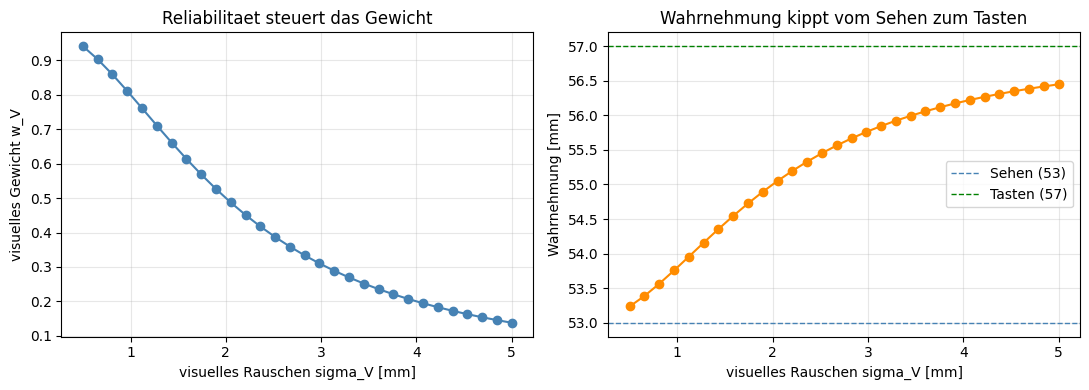

In [5]:
sig_V_range = np.linspace(0.5, 5.0, 30)
wv_curve = [1/sv**2 / (1/sv**2 + 1/2.0**2) for sv in sig_V_range]
percept_curve = [wv*s_V + (1-wv)*s_H for wv in wv_curve]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(sig_V_range, wv_curve, "o-", color="steelblue")
ax1.set_xlabel("visuelles Rauschen sigma_V [mm]"); ax1.set_ylabel("visuelles Gewicht w_V")
ax1.set_title("Reliabilitaet steuert das Gewicht"); ax1.grid(alpha=0.3)
ax2.plot(sig_V_range, percept_curve, "o-", color="darkorange")
ax2.axhline(s_V, color="steelblue", ls="--", lw=1, label="Sehen (53)")
ax2.axhline(s_H, color="green", ls="--", lw=1, label="Tasten (57)")
ax2.set_xlabel("visuelles Rauschen sigma_V [mm]"); ax2.set_ylabel("Wahrnehmung [mm]")
ax2.set_title("Wahrnehmung kippt vom Sehen zum Tasten"); ax2.legend(); ax2.grid(alpha=0.3)
fig.tight_layout(); plt.show()


## Teil C — Diskriminationsgewinn (kleinere JND)

Der dritte Ernst-Banks-Befund: Die **Unterscheidungsschwelle** (just-noticeable difference, JND)
sinkt durch Fusion. Wir testen das mit einer **2-Alternativen-Wahlaufgabe (2AFC)**: Der Beobachter
sieht/tastet zwei Höhen $s$ und $s+\Delta$ und wählt die *größere* — anhand seiner *verrauschten*
Schätzung. Bei Rauschen $\sigma$ ist die Trefferwahrscheinlichkeit theoretisch

$$P(\text{correct}) = \Phi\!\left(\frac{\Delta}{\sigma\sqrt{2}}\right),$$

denn die Differenz zweier unabhängiger $\mathcal{N}(0,\sigma^2)$-Fehler hat Streuung $\sigma\sqrt2$.
Weil $\sigma_{fus}$ am kleinsten ist, ist $P(\text{correct})$ für die Fusion am höchsten — bei
*gleichem* $\Delta$ unterscheidet die Fusion am zuverlässigsten.

Die Zelle ist vorgegeben; führe sie aus und interpretiere.

In [6]:
from math import erf, sqrt
def p_correct(delta, sigma):
    # P(correct) im 2AFC = Phi(delta / (sigma*sqrt(2)))
    z = delta / (sigma * sqrt(2.0))
    return 0.5 * (1 + erf(z / sqrt(2.0)))

delta = 1.0  # zu unterscheidende Hoehendifferenz in mm
for name, sig in [("Sehen", sigma_V), ("Tasten", sigma_H), ("Fusion", sigma_fus_pred)]:
    print(f"{name:7s} (sigma={sig:.3f}): P(correct) bei delta={delta} mm = {p_correct(delta, sig):.3f}")

# JND = Schwelle, bei der P(correct)=0.75 (75%-Punkt). Loese Phi(JND/(sigma*sqrt2))=0.75
from scipy.stats import norm
z75 = norm.ppf(0.75)
print()
for name, sig in [("Sehen", sigma_V), ("Tasten", sigma_H), ("Fusion", sigma_fus_pred)]:
    jnd = z75 * sig * sqrt(2.0)
    print(f"{name:7s}: JND (75%-Schwelle) = {jnd:.3f} mm")


Sehen   (sigma=1.000): P(correct) bei delta=1.0 mm = 0.760
Tasten  (sigma=2.000): P(correct) bei delta=1.0 mm = 0.638
Fusion  (sigma=0.894): P(correct) bei delta=1.0 mm = 0.785



Sehen  : JND (75%-Schwelle) = 0.954 mm
Tasten : JND (75%-Schwelle) = 1.908 mm
Fusion : JND (75%-Schwelle) = 0.853 mm


**Erwartung / Selbstcheck.** Die Fusion hat das kleinste $\sigma$ ($\approx 0.894$), also das
höchste $P(\text{correct})$ und die **kleinste JND** — sie unterscheidet feiner als das Sehen (das
schon beste Einzelmodalität) allein. Das ist *Redundancy Gain* quantifiziert: Zwei Sinne
zusammen sehen schärfer als der schärfere allein.

## Teil D — Der Bogen zurück zu Modul 17

Erinnerung an den **Komplementärfilter** aus Modul 17:
$$\theta = \alpha\,\theta_{\text{Gyro}} + (1-\alpha)\,\theta_{\text{Accel}}.$$
Das ist **dieselbe** gewichtete Fusion wie hier — nur wurde dort $\alpha$ *heuristisch* gewählt.
Die **optimale** Wahl ist die inverse-Varianz-Gewichtung:
$$\alpha^\star = \frac{1/\sigma_{\text{Gyro}}^2}{1/\sigma_{\text{Gyro}}^2 + 1/\sigma_{\text{Accel}}^2} = w_V.$$

Sensorfusion (Modul 17) und multisensorische Wahrnehmung (dieses Modul) sind **dieselbe
Mathematik** — einmal in einem IMU-Chip, einmal im Gehirn.

### Fazit
Du hast die drei Ernst-Banks-Befunde reproduziert:
1. **Präzisionsgewinn**: $\sigma_{fus} \le \min(\sigma_V, \sigma_H)$ (Teil A).
2. **Reliabilitätsadaptiver Wahrnehmungs-Shift** bei Konflikt (Teil B) — der eigentliche Clou.
3. **Kleinere JND / Redundancy Gain** (Teil C).

Damit hast du das mathematische Fundament, auf dem die nächsten beiden Projekte aufbauen:
*late-vs-early Fusion & Mutual Disambiguation* (medium) und die *"Put-that-there"-Referenz­auflösung* (final).